In [1]:
# These two lines allow for the notebook to automatically update to use the most
# up-to-date versions of the code being imported
%load_ext autoreload
%autoreload 2

import control as ct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyphotonicsims.control_systems.control_core import *
from pyphotonicsims.control_systems.calculate_laser_noise import *

# plt.style.available
%matplotlib inline
plt.style.use('science')
plt.rcParams['figure.figsize'] = [4,3]
import matplotlib
matplotlib.rcParams['text.usetex'] = False

c:\Users\lkk12\Documents\code\pyphotonicsims\.venv\Lib\site-packages\control\lti.py:646: FutureWarning: freqresp() is deprecated; use frequency_response()
  warn("freqresp() is deprecated; use frequency_response()", FutureWarning)


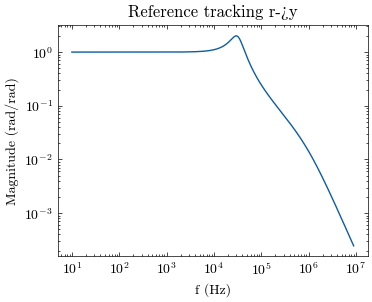

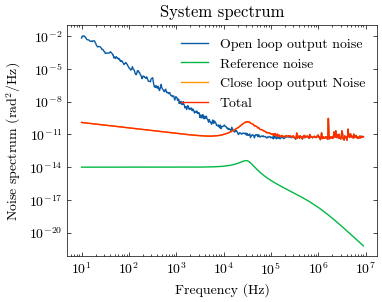

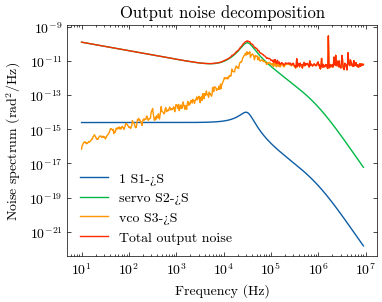

In [2]:
# architechture with the LO as an output
# r ---> D ---> PI ---> LO/VCO ---> y
#        |                |
#        ------------------
# assume both r and VCO have the same noise spectrum

K = 2*np.pi*2e6 # VCO gain 30MHz/V [Hz/V]
BW_vco = 1e6     # VCO BW 1MHz
Dphi = 2         # V/rad
gain = -40       # servo gain
fi = 50e3        # integrator
S_pd = 8e-14     # photocetector noise [Hz^2/Hz]
S_servo = 1e-14  # servo noise [V^2/Hz]
S_mixer = 1e-14  # mixer noise [V^2/Hz]
freq_points = 500
freq1 = 1e1
freq2 = 9e6

D = ControlModule(freq1 = freq1, freq2 = freq2, freq_points = freq_points, sys_ref = 1, unit_in = 'rad', unit_out = 'rad', label = '1')
D.output_noise = np.ones(len(D.freqx))*S_mixer/Dphi**2

s = ct.tf('s')
sys_ref = 10**(gain/20)*(1+2*np.pi*fi/s);
# sys_ref = 0.05*(1 + 2*np.pi*1.8e5/s)
servo = ControlModule(freq1 = freq1, freq2 = freq2, freq_points = freq_points, sys_ref = sys_ref, unit_in = 'V', unit_out = 'V', label = 'servo')
servo.output_noise = np.ones(len(servo.freqx))*S_servo*(1 + (1e4/servo.freqx)**2.5)

sys_ref = K/s/(1+s/(2*np.pi*BW_vco))
vco = ControlModule(freq1 = freq1, freq2 = freq2, freq_points = freq_points, sys_ref = sys_ref, unit_in = 'V', unit_out = 'rad', label = 'vco')

# read from csv to get VCO PN noise
df = pd.read_csv('../data/PLL_ZOS50_VCO.csv')
PN_data = df.values
freq = PN_data[:,0]
PN_data = 10**(PN_data[:,1:]/10)
PNx = S_noise_interp(freq,PN_data[:,1],vco.freqx)
vco.output_noise = PNx
# vco.output_noise = 1e-4/vco.freqx**2 + 1e-14*np.ones(len(vco.freqx))

C_list = [D, servo, vco]
pll = feedback_combine(C_list, 2)
pll.input_noise =  1e-14*np.ones(len(vco.freqx))
pll.freqresp_module_update()

pll.plot_ref_tracking()
pll.plot_module_noise()
pll.plot_module_noise_decomposition()

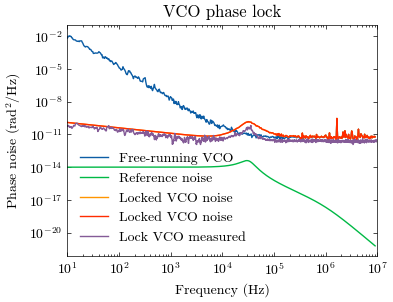

In [3]:
pll.plot_module_noise()
plt.loglog(freq,PN_data[:,2])
plt.legend(('Free-running VCO','Reference noise','Locked VCO noise','Locked VCO noise','Lock VCO measured'), loc = 'lower left')
plt.xlim((10,1e7))
plt.ylabel('Phase noise (rad$^2$/Hz)')
plt.title('VCO phase lock')
plt.savefig('VCO_PLL_lock.png', dpi = 1000, bbox_inches = 'tight')